In [ ]:
# Árbol de decisión para regresión - Videojuegos

En este notebook se presenta el modelo de **árbol de decisión para regresión** en dos escenarios:

1. **Datos sintéticos**: usados en la fase exploratoria para validar el comportamiento del modelo.
2. **Datos reales**: usados en la fase final, cargados desde PostgreSQL.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
## Parte A. Árbol de regresión con datos sintéticos

In [2]:
df = pd.read_csv("../data/videojuegos_sinteticos.csv")

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1000, 10)


,release_year,metascore,price_usd,hours_gameplay,marketing_score,social_hype,discount_pct,bugs_reported,rating_count,rating
0,2021,57.66,45.80,20.71,25.16,16.06,59.39,10,2921,50.00
1,2018,66.93,51.19,50.60,12.59,21.77,24.41,6,1667,51.68
2,2025,59.16,26.25,37.40,9.18,14.66,0.66,6,1090,50.00
3,2022,72.84,38.65,15.34,9.54,9.44,10.19,3,1079,53.04
4,2019,76.17,54.53,113.23,14.37,63.59,39.15,9,2816,64.44


In [3]:
X_reg = df[[
    "metascore",
    "price_usd",
    "hours_gameplay",
    "social_hype",
    "discount_pct",
    "bugs_reported",
    "rating_count"
]]

y_reg = df["rating"]

print("Variables independientes:")
print(X_reg.columns.tolist())
print("\nVariable dependiente:")
print("rating")
print("\nForma de X:", X_reg.shape)
print("Forma de y:", y_reg.shape)

Variables independientes:
['metascore', 'price_usd', 'hours_gameplay', 'social_hype', 'discount_pct', 'bugs_reported', 'rating_count']

Variable dependiente:
rating

Forma de X: (1000, 7)
Forma de y: (1000,)


In [4]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Entrenamiento X:", X_train_reg.shape)
print("Prueba X:", X_test_reg.shape)
print("Entrenamiento y:", y_train_reg.shape)
print("Prueba y:", y_test_reg.shape)

Entrenamiento X: (800, 7)
Prueba X: (200, 7)
Entrenamiento y: (800,)
Prueba y: (200,)


In [5]:
tree_reg = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg.fit(X_train_reg, y_train_reg)

y_pred_reg = tree_reg.predict(X_test_reg)

In [6]:
r2_reg = r2_score(y_test_reg, y_pred_reg)
mse_reg = mean_squared_error(y_test_reg, y_pred_reg)
rmse_reg = np.sqrt(mse_reg)
mae_reg = mean_absolute_error(y_test_reg, y_pred_reg)

print("ÁRBOL DE REGRESIÓN - DATOS SINTÉTICOS")
print("R²:", round(r2_reg, 4))
print("MSE:", round(mse_reg, 4))
print("RMSE:", round(rmse_reg, 4))
print("MAE:", round(mae_reg, 4))

ÁRBOL DE REGRESIÓN - DATOS SINTÉTICOS
R²: 0.652
MSE: 14.8296
RMSE: 3.8509
MAE: 3.0311


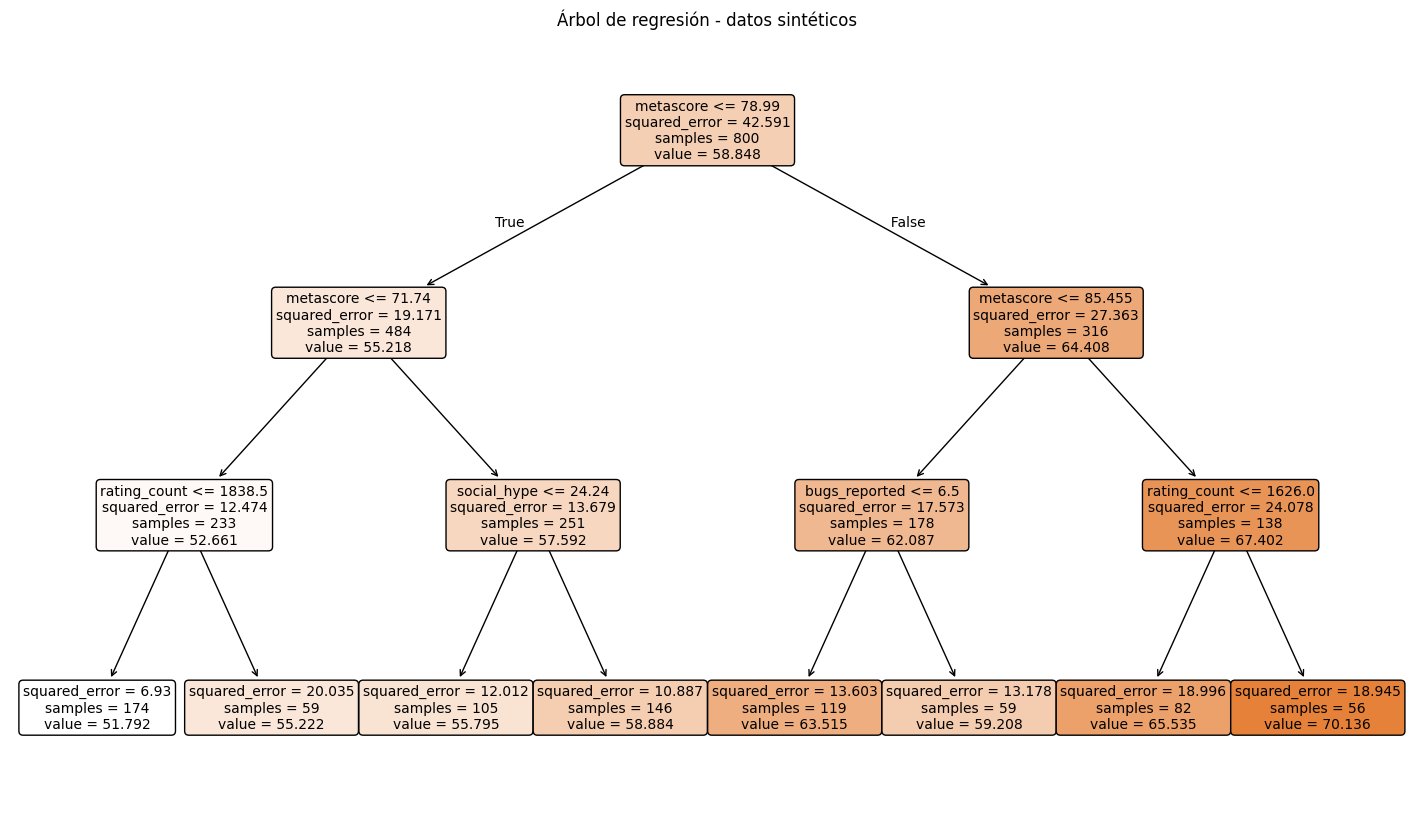

In [7]:
plt.figure(figsize=(18,10))
plot_tree(
    tree_reg,
    feature_names=X_reg.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de regresión - datos sintéticos")
plt.show()

In [8]:
reglas_sinteticas = export_text(tree_reg, feature_names=list(X_reg.columns))
print("REGLAS - ÁRBOL DE REGRESIÓN SINTÉTICO")
print(reglas_sinteticas)

REGLAS - ÁRBOL DE REGRESIÓN SINTÉTICO
|--- metascore <= 78.99
|   |--- metascore <= 71.74
|   |   |--- rating_count <= 1838.50
|   |   |   |--- value: [51.79]
|   |   |--- rating_count >  1838.50
|   |   |   |--- value: [55.22]
|   |--- metascore >  71.74
|   |   |--- social_hype <= 24.24
|   |   |   |--- value: [55.80]
|   |   |--- social_hype >  24.24
|   |   |   |--- value: [58.88]
|--- metascore >  78.99
|   |--- metascore <= 85.45
|   |   |--- bugs_reported <= 6.50
|   |   |   |--- value: [63.51]
|   |   |--- bugs_reported >  6.50
|   |   |   |--- value: [59.21]
|   |--- metascore >  85.45
|   |   |--- rating_count <= 1626.00
|   |   |   |--- value: [65.54]
|   |   |--- rating_count >  1626.00
|   |   |   |--- value: [70.14]



In [ ]:
## Parte B. Árbol de regresión con datos reales desde PostgreSQL

In [9]:
PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Ruta agregada:", PROJECT_ROOT)

Ruta agregada: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos


In [10]:
from scripts.database import engine, test_connection

print("Conexión correcta:", test_connection())

Conexión correcta: True


In [11]:
query = "SELECT * FROM juegos_csv"
df_real = pd.read_sql(query, engine)

print("Dimensiones:", df_real.shape)
df_real.head()

Dimensiones: (99, 10)


,query,id,nombre,fecha_lanzamiento,rating,rating_count,generos,plataformas,cover_url,fecha_extraccion
0,zelda,1022,The Legend of Zelda,509328000.0,80.335612,705.0,Adventure,"Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363358
1,zelda,1025,Zelda II: The Adventure of Link,537580800.0,65.971192,289.0,"Platform, Role-playing (RPG), Adventure","Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363408
2,zelda,1041,The Legend of Zelda: Oracle of Ages,983232000.0,84.269177,164.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363427
3,zelda,1032,The Legend of Zelda: Oracle of Seasons,983232000.0,81.302509,189.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363442
4,zelda,1026,The Legend of Zelda: A Link to the Past,690681600.0,92.332359,1632.0,"Puzzle, Adventure","Satellaview, Super Nintendo Entertainment Syst...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363458


In [12]:
df_model = df_real.copy()

df_model["fecha_lanzamiento"] = pd.to_datetime(
    df_model["fecha_lanzamiento"],
    unit="s",
    errors="coerce"
)

df_model["release_year"] = df_model["fecha_lanzamiento"].dt.year

df_model["genre_count"] = (
    df_model["generos"]
    .fillna("")
    .apply(lambda x: len([g for g in str(x).split(",") if g.strip()]))
)

df_model["platform_count"] = (
    df_model["plataformas"]
    .fillna("")
    .apply(lambda x: len([p for p in str(x).split(",") if p.strip()]))
)

df_model["title_length"] = df_model["nombre"].fillna("").str.len()

print("Dimensiones antes de limpiar:", df_model.shape)
df_model[[
    "nombre", "rating", "rating_count",
    "release_year", "genre_count",
    "platform_count", "title_length"
]].head()

Dimensiones antes de limpiar: (99, 14)


,nombre,rating,rating_count,release_year,genre_count,platform_count,title_length
0,The Legend of Zelda,80.335612,705.0,1986.0,1,6,19
1,Zelda II: The Adventure of Link,65.971192,289.0,1987.0,3,5,31
2,The Legend of Zelda: Oracle of Ages,84.269177,164.0,2001.0,3,2,35
3,The Legend of Zelda: Oracle of Seasons,81.302509,189.0,2001.0,3,2,38
4,The Legend of Zelda: A Link to the Past,92.332359,1632.0,1991.0,2,6,39


In [13]:
df_model = df_model.dropna(subset=["rating", "rating_count", "release_year"]).copy()

print("Dimensiones después de limpiar:", df_model.shape)
df_model[[
    "nombre", "rating", "rating_count",
    "release_year", "genre_count",
    "platform_count", "title_length"
]].head()

Dimensiones después de limpiar: (42, 14)


,nombre,rating,rating_count,release_year,genre_count,platform_count,title_length
0,The Legend of Zelda,80.335612,705.0,1986.0,1,6,19
1,Zelda II: The Adventure of Link,65.971192,289.0,1987.0,3,5,31
2,The Legend of Zelda: Oracle of Ages,84.269177,164.0,2001.0,3,2,35
3,The Legend of Zelda: Oracle of Seasons,81.302509,189.0,2001.0,3,2,38
4,The Legend of Zelda: A Link to the Past,92.332359,1632.0,1991.0,2,6,39


In [14]:
features_real = [
    "release_year",
    "rating_count",
    "genre_count",
    "platform_count",
    "title_length"
]

X_real_reg = df_model[features_real]
y_real_reg = df_model["rating"]

print("X_real_reg:", X_real_reg.shape)
print("y_real_reg:", y_real_reg.shape)
print(X_real_reg.head())

X_real_reg: (42, 5)
y_real_reg: (42,)
   release_year  rating_count  genre_count  platform_count  title_length
0        1986.0         705.0            1               6            19
1        1987.0         289.0            3               5            31
2        2001.0         164.0            3               2            35
3        2001.0         189.0            3               2            38
4        1991.0        1632.0            2               6            39


In [15]:
X_train_real_reg, X_test_real_reg, y_train_real_reg, y_test_real_reg = train_test_split(
    X_real_reg, y_real_reg, test_size=0.2, random_state=42
)

print("Entrenamiento X:", X_train_real_reg.shape)
print("Prueba X:", X_test_real_reg.shape)
print("Entrenamiento y:", y_train_real_reg.shape)
print("Prueba y:", y_test_real_reg.shape)

Entrenamiento X: (33, 5)
Prueba X: (9, 5)
Entrenamiento y: (33,)
Prueba y: (9,)


In [16]:
tree_real_reg = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_real_reg.fit(X_train_real_reg, y_train_real_reg)

y_pred_real_reg = tree_real_reg.predict(X_test_real_reg)

In [17]:
r2_real_reg = r2_score(y_test_real_reg, y_pred_real_reg)
mse_real_reg = mean_squared_error(y_test_real_reg, y_pred_real_reg)
rmse_real_reg = np.sqrt(mse_real_reg)
mae_real_reg = mean_absolute_error(y_test_real_reg, y_pred_real_reg)

print("ÁRBOL DE REGRESIÓN - DATOS REALES")
print("R²:", round(r2_real_reg, 4))
print("MSE:", round(mse_real_reg, 4))
print("RMSE:", round(rmse_real_reg, 4))
print("MAE:", round(mae_real_reg, 4))

ÁRBOL DE REGRESIÓN - DATOS REALES
R²: 0.4506
MSE: 99.4297
RMSE: 9.9714
MAE: 8.7585


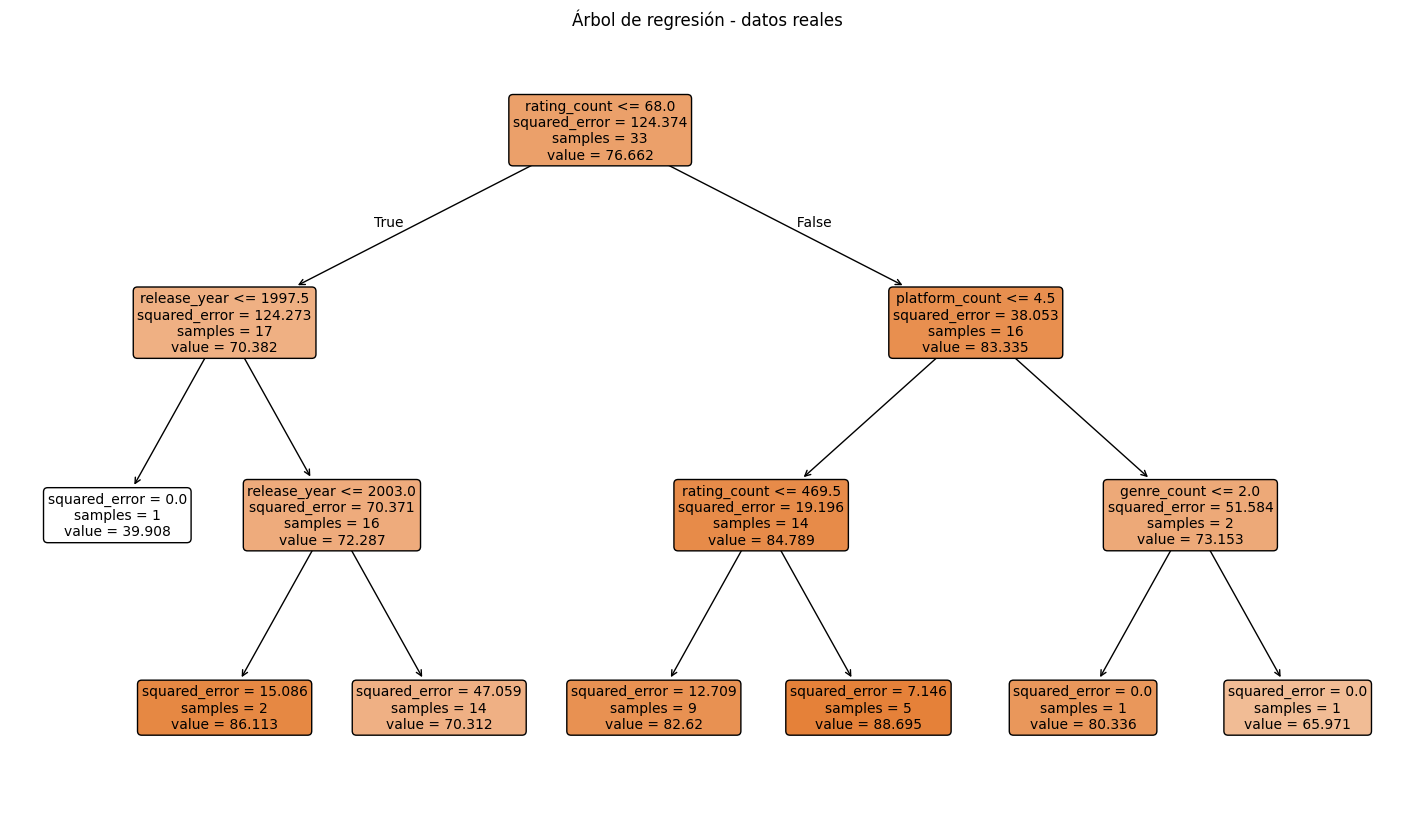

In [18]:
plt.figure(figsize=(18,10))
plot_tree(
    tree_real_reg,
    feature_names=X_real_reg.columns,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de regresión - datos reales")
plt.show()

In [19]:
reglas_reales = export_text(tree_real_reg, feature_names=list(X_real_reg.columns))
print("REGLAS - ÁRBOL DE REGRESIÓN REAL")
print(reglas_reales)

REGLAS - ÁRBOL DE REGRESIÓN REAL
|--- rating_count <= 68.00
|   |--- release_year <= 1997.50
|   |   |--- value: [39.91]
|   |--- release_year >  1997.50
|   |   |--- release_year <= 2003.00
|   |   |   |--- value: [86.11]
|   |   |--- release_year >  2003.00
|   |   |   |--- value: [70.31]
|--- rating_count >  68.00
|   |--- platform_count <= 4.50
|   |   |--- rating_count <= 469.50
|   |   |   |--- value: [82.62]
|   |   |--- rating_count >  469.50
|   |   |   |--- value: [88.69]
|   |--- platform_count >  4.50
|   |   |--- genre_count <= 2.00
|   |   |   |--- value: [80.34]
|   |   |--- genre_count >  2.00
|   |   |   |--- value: [65.97]



In [20]:
comparacion_regresion = pd.DataFrame({
    "Escenario": ["Sintético", "Real"],
    "R²": [r2_reg, r2_real_reg],
    "MSE": [mse_reg, mse_real_reg],
    "RMSE": [rmse_reg, rmse_real_reg],
    "MAE": [mae_reg, mae_real_reg]
})

comparacion_regresion.round(4)

,Escenario,R²,MSE,RMSE,MAE
0,Sintético,0.6520,14.8296,3.8509,3.0311
1,Real,0.4506,99.4297,9.9714,8.7585


In [ ]:
# Conclusión

En este notebook se aplicó el modelo de **árbol de decisión para regresión** en dos contextos:

- **Datos sintéticos**, usados en la etapa exploratoria para validar relaciones entre variables y comportamiento del modelo.
- **Datos reales**, cargados desde PostgreSQL, usados en la etapa final del proyecto.

En ambos casos la variable objetivo fue `rating`.  
En la parte real, el árbol permitió identificar el peso de variables como `rating_count`, `release_year`, `genre_count`, `platform_count` y `title_length`.

Los resultados con datos reales deben interpretarse con cautela, ya que la muestra disponible fue más pequeña y específica que la sintética.